# TEMA 2: MODELOS DE ÁRBOLES APLICADOS A REGRESIÓN
---

Tenemos un dataset que contiene características de casas de California `california_housing.xlsx` y queremos predecir el precio (columna "target").

Este dataset no necesita ningún procesamiento previo: no contiene nulos, todas las variables son numéricas, y no necesita estandarización (ya que los algoritmos basados en árboles no son sensibles a la escala)

In [ ]:
#pip install xgboost

In [40]:
# Importing the libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import pickle

In [2]:
housing = pd.read_excel('california_housing.xlsx')

In [3]:
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23,4.526
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22,3.585
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24,3.521
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25,3.413
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25,3.422


### Dividimos muestra en train y test

In [4]:
x = housing.drop('target', axis = 1) # Features
y = housing['target']  # Target

# Splitting the dataset into training and testing set (70/30)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 0)

## 1. Árbol de decisión
---

### Ajustamos modelo

In [5]:
tree = DecisionTreeRegressor()

tree.fit(x_train, y_train)

DecisionTreeRegressor()

### Evaluamos el modelo

Como los modelos basados en árboles tienen un alto riesgo de incurrir en sobreajuste, conviene evaluarlos tanto en train como en test:

In [6]:
y_train_pred_tree = tree.predict(x_train)
y_test_pred_tree = tree.predict(x_test)

print('La R^2 en los datos de train es: {}'.format(np.round(r2_score(y_train, y_train_pred_tree),2))) 
print('La R^2 en los datos de test es: {}'.format(np.round(r2_score(y_test, y_test_pred_tree),2))) 

La R^2 en los datos de train es: 1.0
La R^2 en los datos de test es: 0.59


**PREGUNTA 1**: ¿Qué nos indica la diferencia entre el R cuadrado obtenido en train y test? ¿Es un buen resultado?

El modelo está completamente sobreajustado sobre los datos de train.

### Ajustamos hiperparámetros

In [7]:
params = {"max_depth": range(1, 8), "min_samples_leaf": [1,5,8,12]}

tree_cv = GridSearchCV(tree, params, cv=3)

tree_cv.fit(x_train, y_train) 

tree_cv.best_params_

{'max_depth': 7, 'min_samples_leaf': 12}

Ajustamos el árbol con los parámetros elegidos:

In [8]:
tree = DecisionTreeRegressor(max_depth = tree_cv.best_params_['max_depth'], 
                             min_samples_leaf = tree_cv.best_params_['min_samples_leaf'])
tree.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=7, min_samples_leaf=12)

In [9]:
y_train_pred_tree = tree.predict(x_train) 
y_test_pred_tree = tree.predict(x_test)

print('La R^2 en los datos de train es: {}'.format(np.round(r2_score(y_train, y_train_pred_tree),2))) 
print('La R^2 en los datos de test es: {}'.format(np.round(r2_score(y_test, y_test_pred_tree),2))) 

print('El RMSE en los datos de train es: {}'.format(np.round(np.sqrt(mean_squared_error(y_train, y_train_pred_tree)),2)))
print('El RMSE en los datos de test es: {}'.format(np.round(np.sqrt(mean_squared_error(y_test, y_test_pred_tree)),2)))

La R^2 en los datos de train es: 0.71
La R^2 en los datos de test es: 0.66
El RMSE en los datos de train es: 0.62
El RMSE en los datos de test es: 0.67


Otro output interesante a la hora de entender los algoritmos es la importancia de variables:

In [11]:
tree.feature_importances_

array([0.71210117, 0.04006776, 0.0311245 , 0.00384366, 0.0018455 ,
       0.1386572 , 0.04132375, 0.03103645])

In [10]:
pd.DataFrame({"variable": x_train.columns, "importancia relativa": tree.feature_importances_}) \
.sort_values(by='importancia relativa', ascending = False)

,variable,importancia relativa
0,MedInc,0.712101
5,AveOccup,0.138657
6,Latitude,0.041324
1,HouseAge,0.040068
2,AveRooms,0.031125
7,Longitude,0.031036
3,AveBedrms,0.003844
4,Population,0.001846


Esta medida proporciona la importancia (% de contribución) de cada feature en la toma de decisiones del árbol: contribución de cada característica a reducir la impureza o la varianza en el conjunto de datos.

En este caso, la variable más relevante a la hora de predecir el precio son los ingresos medios del barrio donde se localiza la casa.

In [16]:
from sklearn.tree import plot_tree

[Text(0.5598569651741293, 0.9375, 'x[0] <= 5.029\nsquared_error = 1.331\nsamples = 14448\nvalue = 2.068'),
 Text(0.2960199004975124, 0.8125, 'x[0] <= 3.067\nsquared_error = 0.828\nsamples = 11381\nvalue = 1.732'),
 Text(0.14987562189054726, 0.6875, 'x[2] <= 4.216\nsquared_error = 0.545\nsamples = 5469\nvalue = 1.35'),
 Text(0.07960199004975124, 0.5625, 'x[5] <= 2.504\nsquared_error = 0.656\nsamples = 2059\nvalue = 1.641'),
 Text(0.03980099502487562, 0.4375, 'x[0] <= 2.19\nsquared_error = 1.001\nsamples = 651\nvalue = 2.025'),
 Text(0.01990049751243781, 0.3125, 'x[2] <= 3.326\nsquared_error = 0.884\nsamples = 294\nvalue = 1.672'),
 Text(0.009950248756218905, 0.1875, 'x[4] <= 1208.0\nsquared_error = 1.093\nsamples = 122\nvalue = 2.02'),
 Text(0.004975124378109453, 0.0625, 'squared_error = 0.657\nsamples = 84\nvalue = 1.748'),
 Text(0.014925373134328358, 0.0625, 'squared_error = 1.532\nsamples = 38\nvalue = 2.622'),
 Text(0.029850746268656716, 0.1875, 'x[5] <= 1.969\nsquared_error = 0.589

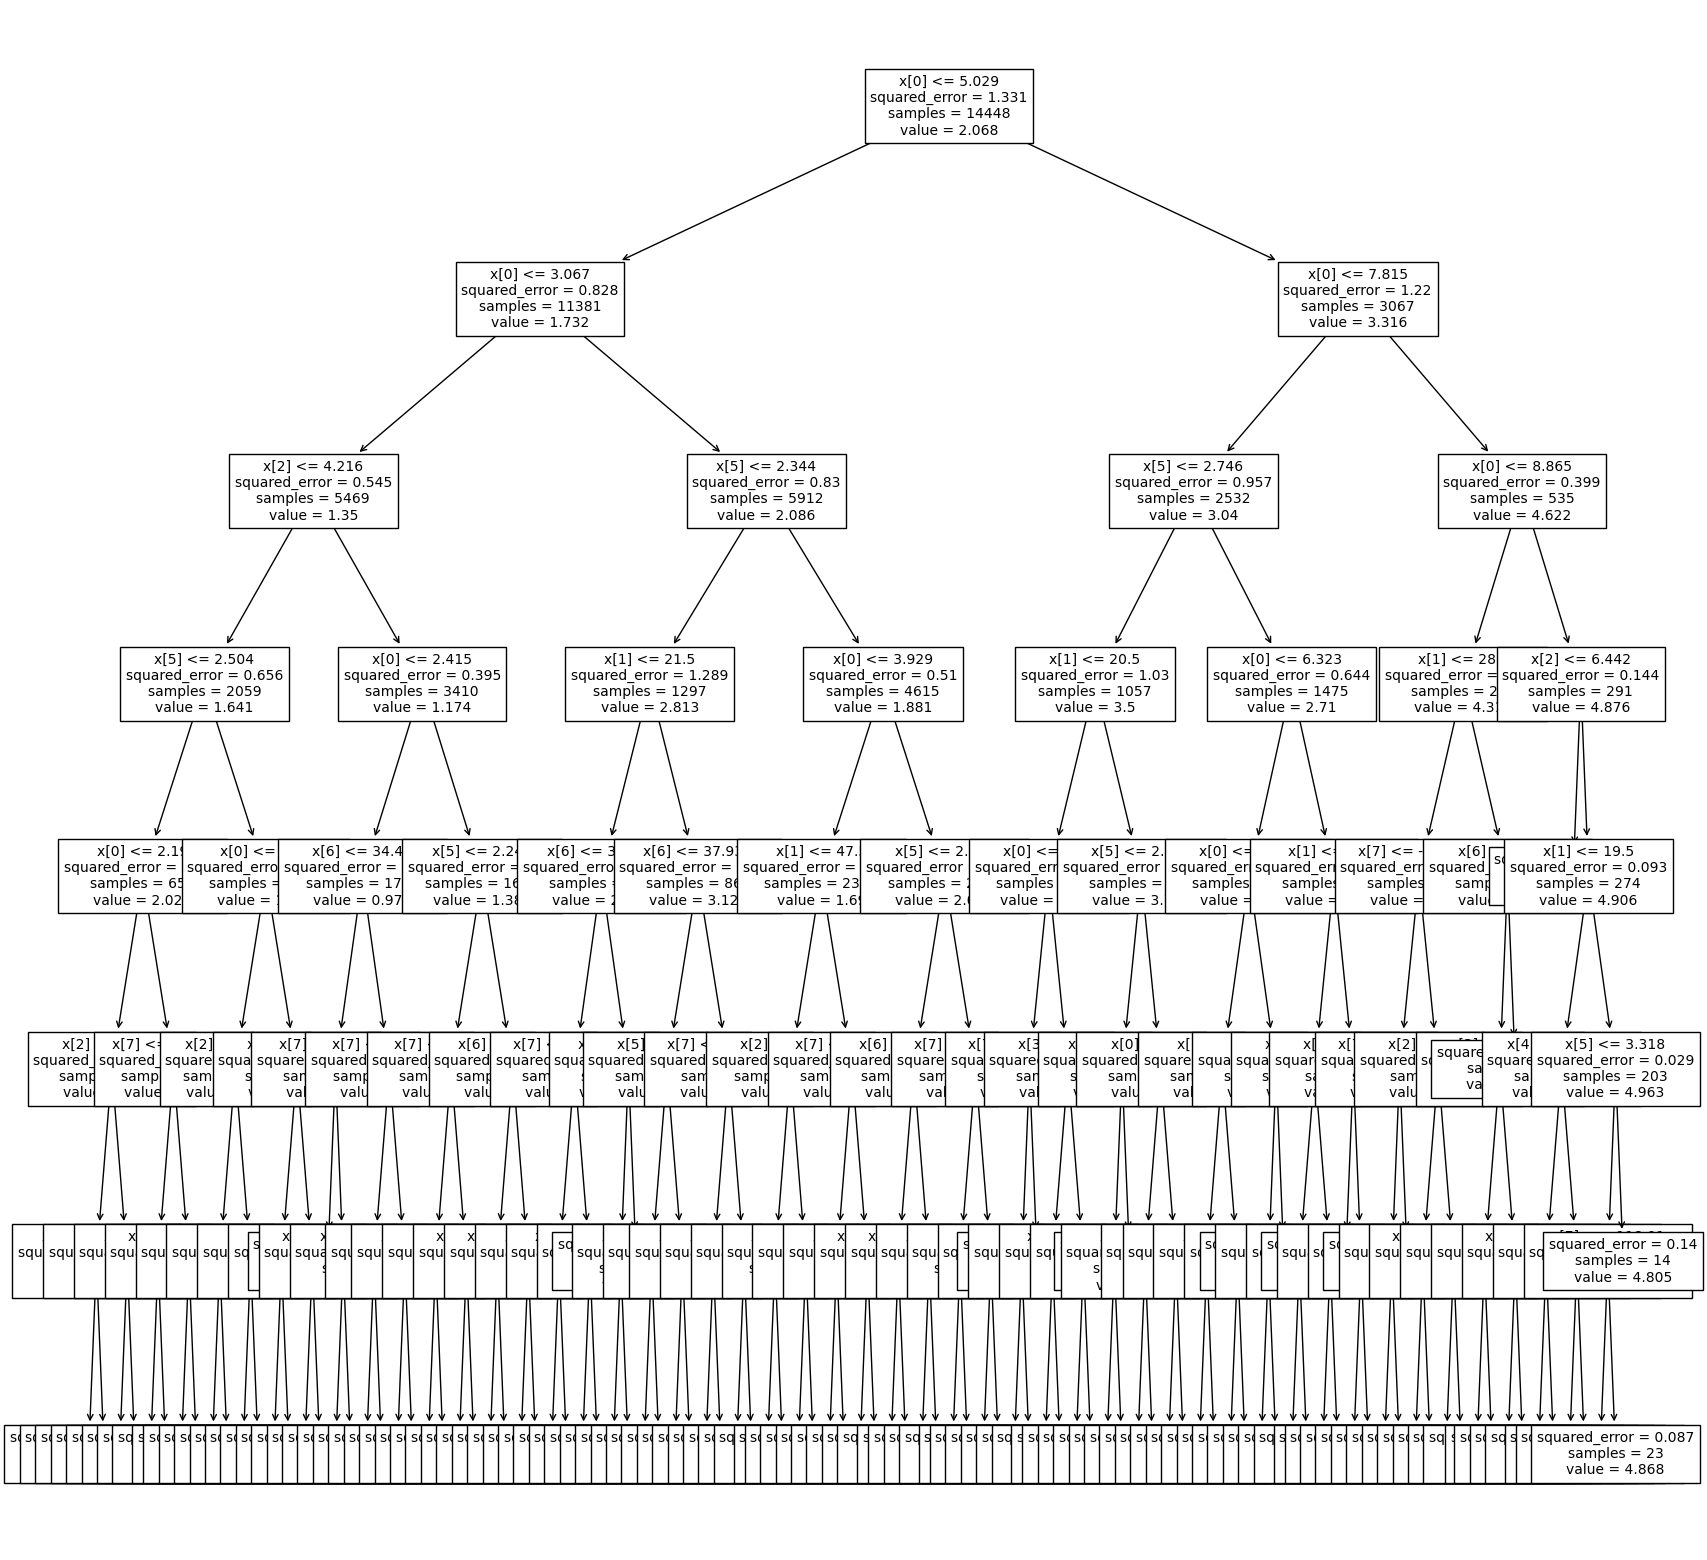

In [19]:
plt.figure(figsize=(20,20))
plot_tree(tree, fontsize=10)

## 2. Random Forest
---

In [12]:
rf = RandomForestRegressor()

rf.fit(x_train, y_train)

RandomForestRegressor()

In [13]:
y_train_pred_rf = rf.predict(x_train) 
y_test_pred_rf = rf.predict(x_test) 

print('La R^2 en los datos de train es: {}'.format(np.round(r2_score(y_train, y_train_pred_rf),2))) 
print('La R^2 en los datos de test es: {}'.format(np.round(r2_score(y_test, y_test_pred_rf),2)))

La R^2 en los datos de train es: 0.97
La R^2 en los datos de test es: 0.79


Como está sobreajustado, probamos a optimizar los hiperparámetros. En lugar de buscar hiperparámetros con Grid Search (que para algoritmos ensamblados suele ser bastante costoso computacionalmente), probamos directamente a tocar los hiperparámetros que sabemos que reducen el sobreajuste:

- Aumentar el nº de árboles (por defecto es 100)
- Aumentar el nº mínimo de observaciones en un nodo para hacer una división (por defecto es 2)
- Disminuir el % de variables a considerar en cada división (por defecto es 1, el 100%).

Aumentar el nº de árboles y el número de observaciones mínimo para hacer una división suele reducir el sobreajuste 

In [14]:
rf = RandomForestRegressor(n_estimators = 300, min_samples_split = 50, max_features = 0.8)

rf.fit(x_train, y_train)

RandomForestRegressor(max_features=0.8, min_samples_split=50, n_estimators=300)

In [15]:
y_train_pred_rf = rf.predict(x_train) 
y_test_pred_rf = rf.predict(x_test) 

print('La R^2 en los datos de train es: {}'.format(np.round(r2_score(y_train, y_train_pred_rf),2))) 
print('La R^2 en los datos de test es: {}'.format(np.round(r2_score(y_test, y_test_pred_rf),2)))

print('El MSE en los datos de train es: {}'.format(np.round(np.sqrt(mean_squared_error(y_train, y_train_pred_rf)),2)))
print('El MSE en los datos de test es: {}'.format(np.round(np.sqrt(mean_squared_error(y_test, y_test_pred_rf)),2)))

La R^2 en los datos de train es: 0.85
La R^2 en los datos de test es: 0.78
El MSE en los datos de train es: 0.44
El MSE en los datos de test es: 0.55


Con Random Forest conseguimos mejorar las predicciones del árbol simple (de un 65% a un 78% de R cuadrado en test).

**PREGUNTA 2**: Haz varias pruebas con distintos valores de los hiperparámetros. ¿Consigues mejorar el resultado en términos de sobreajuste y performance en test?

In [28]:
# resolver

rf = RandomForestRegressor(n_estimators = 250, min_samples_split = 40, max_features = 0.7)

rf.fit(x_train, y_train)

RandomForestRegressor(max_features=0.7, min_samples_split=40, n_estimators=250)

In [29]:
y_train_pred_rf = rf.predict(x_train) 
y_test_pred_rf = rf.predict(x_test) 

print('La R^2 en los datos de train es: {}'.format(np.round(r2_score(y_train, y_train_pred_rf),2))) 
print('La R^2 en los datos de test es: {}'.format(np.round(r2_score(y_test, y_test_pred_rf),2)))

La R^2 en los datos de train es: 0.87
La R^2 en los datos de test es: 0.78


In [ ]:
# prueba 1: 0.86, 0.79
# prueba 2: 0.84, 0.78
# prueba 3

In [30]:
rf = RandomForestRegressor()

params = {"n_estimators": [100,300,400], "min_samples_split": [40,50,60],
          "max_features": [0.6, 0.7, 0.8]}

rf_cv = GridSearchCV(rf, params, cv=3)

rf_cv.fit(x_train, y_train) 

rf_cv.best_params_

{'max_features': 0.6, 'min_samples_split': 40, 'n_estimators': 400}

## 3. XGBoost
---

In [31]:
xgb = XGBRegressor()

xgb.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [32]:
y_train_pred_xgb = xgb.predict(x_train) 
y_test_pred_xgb = xgb.predict(x_test) 

print('La R^2 en los datos de train es: {}'.format(np.round(r2_score(y_train, y_train_pred_xgb),2))) 
print('La R^2 en los datos de test es: {}'.format(np.round(r2_score(y_test, y_test_pred_xgb),2)))

La R^2 en los datos de train es: 0.95
La R^2 en los datos de test es: 0.83


Pruebo a disminuir el parámetro de velocidad de aprendizaje, la profundidad máxima y la proporción de columnas a utilizar para tratar de reducir el sobreajuste:

In [33]:
xgb = XGBRegressor(eta = 0.1, max_depth = 5, colsample_bytree = 0.6)

xgb.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eta=0.1, eval_metric=None,
             feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [34]:
y_train_pred_xgb = xgb.predict(x_train) 
y_test_pred_xgb = xgb.predict(x_test) 

print('La R^2 en los datos de train es: {}'.format(np.round(r2_score(y_train, y_train_pred_xgb),2))) 
print('La R^2 en los datos de test es: {}'.format(np.round(r2_score(y_test, y_test_pred_xgb),2)))

print('El MSE en los datos de train es: {}'.format(np.round(np.sqrt(mean_squared_error(y_train, y_train_pred_xgb)),2)))
print('El MSE en los datos de test es: {}'.format(np.round(np.sqrt(mean_squared_error(y_test, y_test_pred_xgb)),2)))

La R^2 en los datos de train es: 0.86
La R^2 en los datos de test es: 0.82
El MSE en los datos de train es: 0.43
El MSE en los datos de test es: 0.5


Con xgboost conseguimos mejorar las predicciones del random forest, con un R cuadrado en test de 86% (frente al 78% anterior).

### Predicciones sobre nuevos datos

In [45]:
pickle.dump(xgb, open('modelo_xgb.pkl', "wb")) # guardar

In [46]:
modelo = pickle.load(open('modelo_xgb.pkl', "rb")) # leer

In [47]:
df = housing[1:100].drop('target', axis = 1)

In [48]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25
5,4.0368,52,4.761658,1.103627,413,2.139896,37.85,-122.25
...,...,...,...,...,...,...,...,...
95,2.0096,36,2.294016,1.066294,3469,1.493328,37.80,-122.26
96,2.8345,31,3.894915,1.127966,2048,1.735593,37.82,-122.26
97,2.0062,29,3.681319,1.175824,202,2.219780,37.81,-122.26
98,1.2185,22,2.945600,1.016000,2024,1.619200,37.82,-122.26


In [49]:
pred = modelo.predict(df)

In [50]:
pred

array([4.046309  , 4.064751  , 3.1404083 , 2.6976323 , 2.4487095 ,
       2.393279  , 2.5414386 , 1.6876745 , 2.5654285 , 2.2893894 ,
       2.4593172 , 2.0131464 , 2.0198214 , 1.831322  , 1.3225543 ,
       1.9155014 , 1.6897333 , 1.5296075 , 1.6593947 , 1.2866627 ,
       1.2414774 , 1.6439158 , 1.4089677 , 1.7596132 , 1.5014919 ,
       1.4290581 , 1.3541062 , 1.432875  , 1.2874868 , 1.4569744 ,
       1.3757421 , 1.0507579 , 1.424558  , 1.7548256 , 1.4739847 ,
       1.1868621 , 1.6214471 , 2.166951  , 2.2103586 , 1.5557594 ,
       1.6339396 , 1.5249684 , 2.2024717 , 1.9299868 , 2.2250516 ,
       1.7175077 , 1.5668932 , 1.2827392 , 1.8259524 , 1.8841048 ,
       1.201041  , 1.2846967 , 1.2518048 , 1.1517045 , 1.330153  ,
       1.5189786 , 1.2014511 , 1.0450902 , 1.3364259 , 1.8905822 ,
       2.7268422 , 0.95770204, 1.3535976 , 1.3006816 , 1.0441865 ,
       1.330821  , 1.4892018 , 1.1006172 , 1.1412458 , 1.1570976 ,
       1.4771292 , 0.8651158 , 1.4212444 , 1.9563019 , 1.64155